<a href="https://colab.research.google.com/github/tanmayrathi/ML_PROJECT_TAE1/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/ML_DATASETS/healthcare-dataset-stroke-data.csv'

In [ ]:
!pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv(file_path)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

/tmp/ipykernel_2803/3594416367.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


In [ ]:
le = LabelEncoder()

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.drop('id', axis=1, inplace=True)

In [ ]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X, y = smote.fit_resample(X, y)

In [ ]:
for split in [0.3, 0.2]:
    print(f"\n===== Train-Test Split {(1-split)*100:.0f}:{split*100:.0f} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=42
    )

    # Random Forest Model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


===== Train-Test Split 70:30 =====
Accuracy: 0.9406924922865958

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94      1457
           1       0.93      0.96      0.94      1460

    accuracy                           0.94      2917
   macro avg       0.94      0.94      0.94      2917
weighted avg       0.94      0.94      0.94      2917


Confusion Matrix:
 [[1346  111]
 [  62 1398]]

===== Train-Test Split 80:20 =====
Accuracy: 0.9491002570694087

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95       975
           1       0.93      0.97      0.95       970

    accuracy                           0.95      1945
   macro avg       0.95      0.95      0.95      1945
weighted avg       0.95      0.95      0.95      1945


Confusion Matrix:
 [[908  67]
 [ 32 938]]


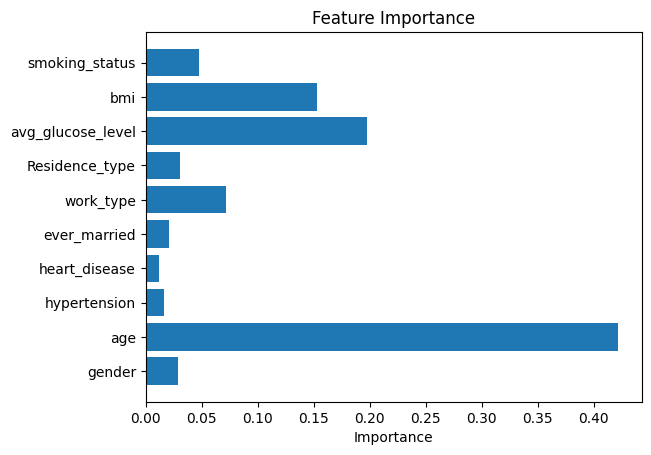

In [ ]:
#Feature importance
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

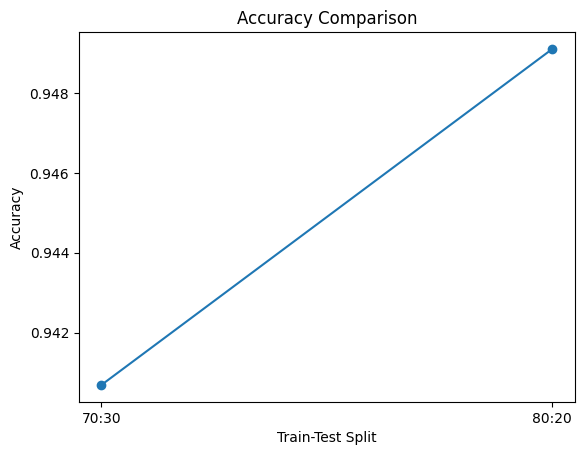

In [ ]:
splits = [0.3, 0.2]
accuracies = []

for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=42
    )

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure()
plt.plot(['70:30', '80:20'], accuracies, marker='o')
plt.xlabel("Train-Test Split")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()